# Mushroom Species Recognition
**SDG 3 - Good Health & Well-being | SDG 15 - Life on Land**

This notebook trains an image classifier to identify mushroom species from photos using transfer learning (EfficientNet-B3).

In [5]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Data Loading & Reduction

The full dataset contains 100+ species. We keep the **50 most frequent classes** with a maximum of 100 training images and 30 validation images per class to balance training coverage and GPU time.

This gives **5,000 training images** and **1,500 validation images**.

In [6]:
BASE_PATH = '/kaggle/input/datasets/zlatan599/mushroom1/'

train_df = pd.read_csv(BASE_PATH + 'train.csv')
val_df   = pd.read_csv(BASE_PATH + 'val.csv')
test_df  = pd.read_csv(BASE_PATH + 'test.csv')

def sample_dataset(df, n_classes=50, samples_per_class=100):
    top_classes = df['label'].value_counts().head(n_classes).index
    df_filtered = df[df['label'].isin(top_classes)]
    return df_filtered.groupby('label').head(samples_per_class).reset_index(drop=True)

train_small = sample_dataset(train_df, n_classes=50, samples_per_class=100)

train_classes = set(train_small['label'].unique())
val_filtered  = val_df[val_df['label'].isin(train_classes)]
val_small     = val_filtered.groupby('label').head(30).reset_index(drop=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_small['label_enc'] = le.fit_transform(train_small['label'])
val_small['label_enc']   = le.transform(val_small['label'])

NUM_CLASSES = len(le.classes_)
print(f"Classes dans train : {NUM_CLASSES}")
print(f"Images train : {len(train_small)} | Images val : {len(val_small)}")

Classes dans train : 50
Images train : 5000 | Images val : 1500


## 2. Path Correction

Image paths in the CSV point to `/kaggle/working/` which does not exist at runtime. We remap them to the correct Kaggle input directory.

In [7]:
train_small['image_path'] = train_small['image_path'].str.replace(
    '/kaggle/working/', 
    '/kaggle/input/datasets/zlatan599/mushroom1/', 
    regex=False
)
val_small['image_path'] = val_small['image_path'].str.replace(
    '/kaggle/working/', 
    '/kaggle/input/datasets/zlatan599/mushroom1/', 
    regex=False
)

print(train_small['image_path'][0])
print(os.path.exists(train_small['image_path'][0]))

/kaggle/input/datasets/zlatan599/mushroom1/merged_dataset/Lycoperdon perlatum/34356medium.jpg
True


## 3. Preprocessing & Data Augmentation

Training images are augmented (flip, rotation, color jitter) to improve generalization. Validation images use only resize and normalize. All images are resized to **224×224** and normalized with ImageNet statistics.

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class MushroomDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df['image_path'][idx]
        img      = Image.open(img_path).convert('RGB')
        label    = self.df['label_enc'][idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_loader = DataLoader(MushroomDataset(train_small, train_transform),
                          batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(MushroomDataset(val_small,   val_transform),
                          batch_size=32, shuffle=False, num_workers=2)

## 4. Model - EfficientNet-B3 (Transfer Learning)

We load EfficientNet-B3 pretrained on ImageNet and replace the final layer for our 50-class problem. All backbone weights are frozen at this stage — only the new classification head will be trained first.

In [9]:
model = models.efficientnet_b3(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 182MB/s]


## 5. Training - Phase 1: Head Only (5 epochs)

Only the classification head is trained with `lr=1e-3`. This lets the model quickly adapt to the mushroom classes without disturbing the pretrained features.

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

EPOCHS = 5
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(EPOCHS):
    tl, ta = train_epoch(model, train_loader)
    vl, va = eval_epoch(model,  val_loader)
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta);   val_accs.append(va)
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {tl:.3f} Acc: {ta:.3f} | "
          f"Val Loss: {vl:.3f} Acc: {va:.3f}")

100%|██████████| 157/157 [00:33<00:00,  4.65it/s]


Epoch 1/5 | Train Loss: 3.116 Acc: 0.316 | Val Loss: 2.427 Acc: 0.520


100%|██████████| 157/157 [00:21<00:00,  7.20it/s]


Epoch 2/5 | Train Loss: 2.111 Acc: 0.547 | Val Loss: 1.878 Acc: 0.585


100%|██████████| 157/157 [00:22<00:00,  6.84it/s]


Epoch 3/5 | Train Loss: 1.711 Acc: 0.602 | Val Loss: 1.639 Acc: 0.603


100%|██████████| 157/157 [00:22<00:00,  6.90it/s]


Epoch 4/5 | Train Loss: 1.504 Acc: 0.636 | Val Loss: 1.514 Acc: 0.623


100%|██████████| 157/157 [00:22<00:00,  6.88it/s]


Epoch 5/5 | Train Loss: 1.363 Acc: 0.658 | Val Loss: 1.433 Acc: 0.621


## 6. Training - Phase 2: Fine-Tuning (5 epochs)

The last 3 backbone blocks are unfrozen and trained with a lower `lr=1e-4`. This allows the model to refine deeper visual features specific to mushroom textures and shapes.

In [11]:
for param in model.features[-3:].parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=1e-4
)

EPOCHS_FT = 5
for epoch in range(EPOCHS_FT):
    tl, ta = train_epoch(model, train_loader)
    vl, va = eval_epoch(model, val_loader)
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta);   val_accs.append(va)
    print(f"FT Epoch {epoch+1}/{EPOCHS_FT} | "
          f"Train Loss: {tl:.3f} Acc: {ta:.3f} | "
          f"Val Loss: {vl:.3f} Acc: {va:.3f}")

100%|██████████| 157/157 [00:25<00:00,  6.28it/s]


FT Epoch 1/5 | Train Loss: 1.005 Acc: 0.722 | Val Loss: 0.909 Acc: 0.733


100%|██████████| 157/157 [00:24<00:00,  6.35it/s]


FT Epoch 2/5 | Train Loss: 0.689 Acc: 0.799 | Val Loss: 0.781 Acc: 0.763


100%|██████████| 157/157 [00:24<00:00,  6.46it/s]


FT Epoch 3/5 | Train Loss: 0.550 Acc: 0.842 | Val Loss: 0.730 Acc: 0.773


100%|██████████| 157/157 [00:24<00:00,  6.40it/s]


FT Epoch 4/5 | Train Loss: 0.443 Acc: 0.871 | Val Loss: 0.683 Acc: 0.793


100%|██████████| 157/157 [00:24<00:00,  6.35it/s]


FT Epoch 5/5 | Train Loss: 0.362 Acc: 0.902 | Val Loss: 0.649 Acc: 0.801


## 7. Learning Curves

Loss and accuracy plotted over all 10 epochs. Both train and val curves decrease together - no overfitting detected.

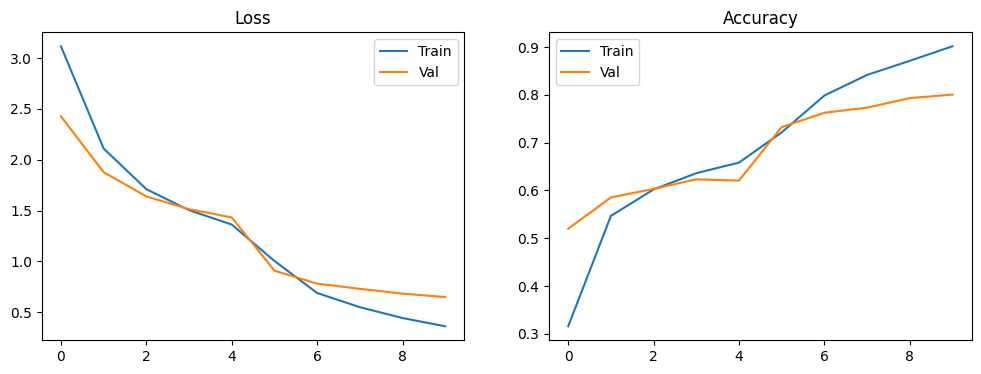

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train'); ax1.plot(val_losses, label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(train_accs,  label='Train'); ax2.plot(val_accs,  label='Val')
ax2.set_title('Accuracy'); ax2.legend()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 8. Evaluation - Confusion Matrix & Classification Report

Final evaluation on the validation set (1,500 images, 50 classes). The confusion matrix shows the top 10 classes. Overall accuracy: **80%**, macro F1-score: **0.80**.

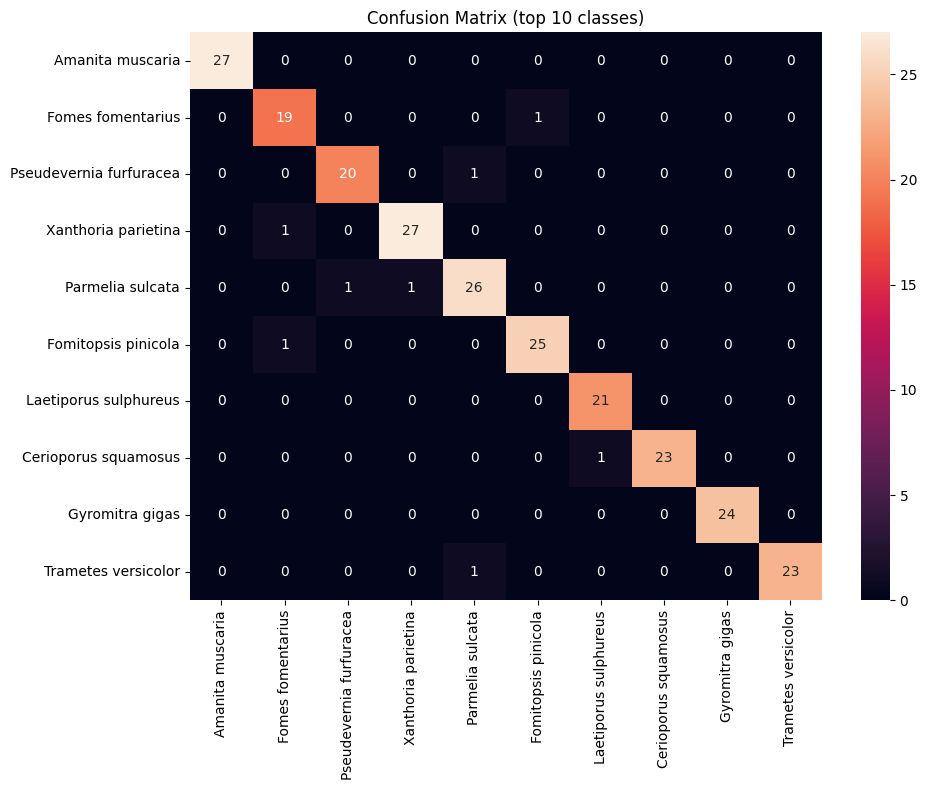

                             precision    recall  f1-score   support

            Amanita augusta       0.85      0.73      0.79        30
      Amanita calyptroderma       0.70      0.77      0.73        30
            Amanita citrina       0.67      0.97      0.79        30
           Amanita muscaria       0.90      0.90      0.90        30
         Amanita pantherina       0.87      0.87      0.87        30
             Boletus edulis       0.76      0.63      0.69        30
       Cerioporus squamosus       0.85      0.77      0.81        30
Chlorociboria aeruginascens       0.88      0.93      0.90        30
     Chlorophyllum brunneum       0.74      0.87      0.80        30
       Coprinellus micaceus       0.84      0.70      0.76        30
    Daedaleopsis confragosa       0.57      0.43      0.49        30
          Evernia prunastri       0.64      0.60      0.62        30
          Fomes fomentarius       0.68      0.63      0.66        30
        Fomitopsis betulina      

In [14]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

from collections import Counter
top10_idx = [i for i, _ in Counter(all_labels).most_common(10)]
mask = [i for i, l in enumerate(all_labels) if l in top10_idx]
preds_10  = [all_preds[i]  for i in mask]
labels_10 = [all_labels[i] for i in mask]

cm = confusion_matrix(labels_10, preds_10, labels=top10_idx)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_[top10_idx],
            yticklabels=le.classes_[top10_idx])
plt.title('Confusion Matrix (top 10 classes)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(all_labels, all_preds,
                             target_names=le.classes_))

## 9. Save model & label encoder

Download these two files from Kaggle after training, they are everything needed for deployment.

In [15]:
import pickle

torch.save(model.state_dict(), 'mushroom_efficientnet_b3.pth')

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Saved:")
print("  mushroom_efficientnet_b3.pth  ← model weights (~50 MB)")
print("  label_encoder.pkl             ← species name mapping")

Saved:
  mushroom_efficientnet_b3.pth  ← model weights (~50 MB)
  label_encoder.pkl             ← species name mapping
